In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain

from msfm.utils import files, parameters
from msi.utils import plotting

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

In [32]:
# mock = "Buzzard_0"
mock = "Buzzard_3"
# mock = "Buzzard_7"

# base_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended"
base_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended"

steps = 400_000
network_dir = os.path.join(base_dir, f"lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/{steps}_steps_likelihood_sigmoid")
wl_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
wl_params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

steps = 240_000
network_dir = os.path.join(base_dir, f"clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/{steps}_steps_likelihood_sigmoid")
gc_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
gc_params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

steps = 400_000
network_dir = os.path.join(base_dir, f"combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/{steps}_steps_likelihood_sigmoid")
cp_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
cp_params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]


# plot

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

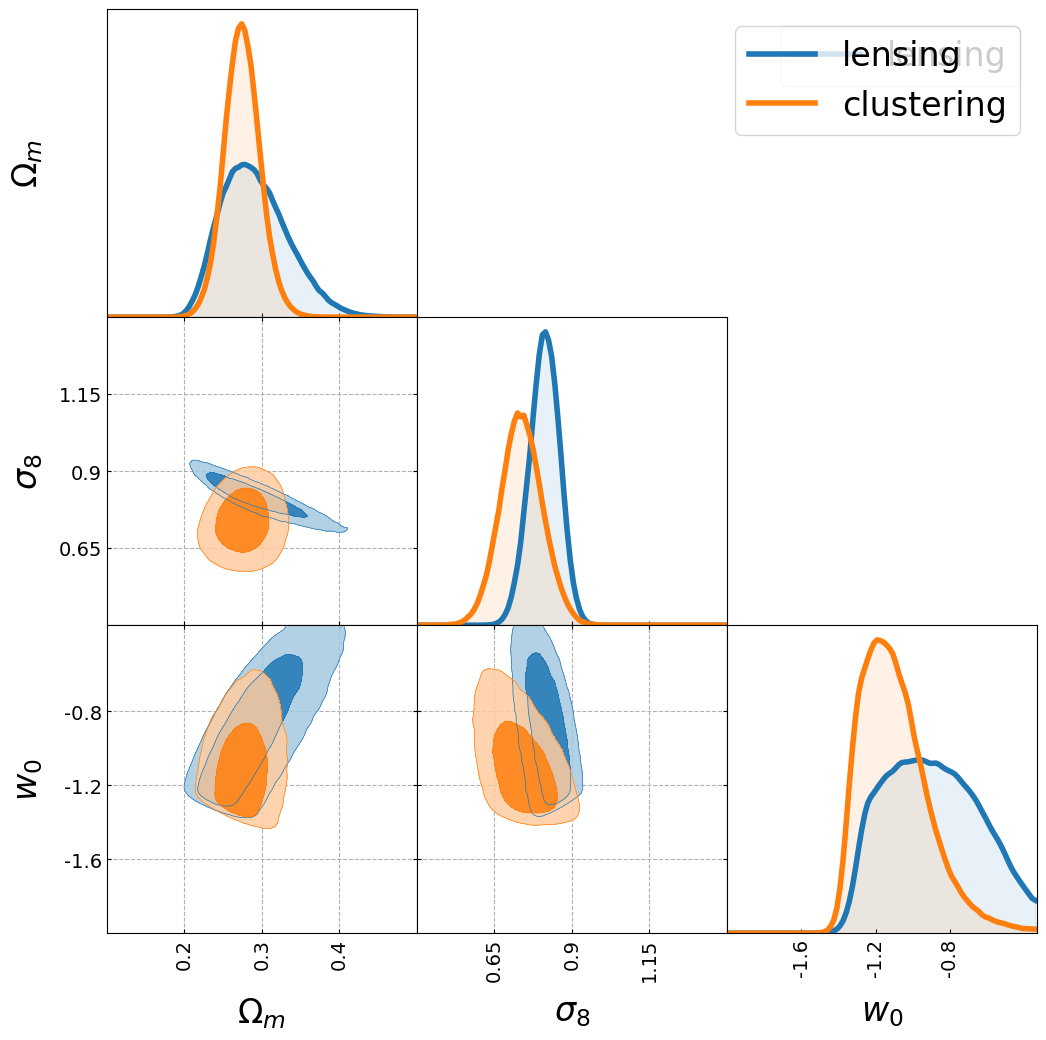

In [33]:
# all_params = cp_params
all_params = ["Om", "s8", "w0"]

ranges = dict(zip(all_params, parameters.get_prior_intervals(all_params, conf=conf)))
param_label_dict = plotting.param_label_dict

tri = TriangleChain(
    params=all_params,
    ranges=ranges,
    fill=True,
    grid=True,
    show_legend=True,
    labels=[param_label_dict[param] for param in all_params],
)

tri.contour_cl(wl_chain, names=wl_params, label="lensing");
tri.contour_cl(gc_chain, names=gc_params, label="clustering");
# tri.contour_cl(cp_chain, names=cp_params, label="combined");

# tensiometer

In [34]:
# based on https://tensiometer.readthedocs.io/en/latest/example_non_gaussian_tension.html
# https://arxiv.org/abs/2105.03324

import getdist
from getdist.mcsamples import MCSamples

import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer import mcmc_tension

In [35]:
wl_samples = MCSamples(samples=wl_chain, names=wl_params)
gc_samples = MCSamples(samples=gc_chain, names=gc_params)
# wl_samples = MCSamples(samples=wl_chain[::100], names=wl_params)
# gc_samples = MCSamples(samples=gc_chain[::100], names=gc_params)

diff_chain = mcmc_tension.parameter_diff_chain(wl_samples, gc_samples, boost=4)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: ylabel='delta_Om'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='delta_s8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='delta_Om', ylabel='delta_w0'>,
         <Axes: xlabel='delta_s8'>, <Axes: xlabel='delta_w0'>]],
       dtype=object))

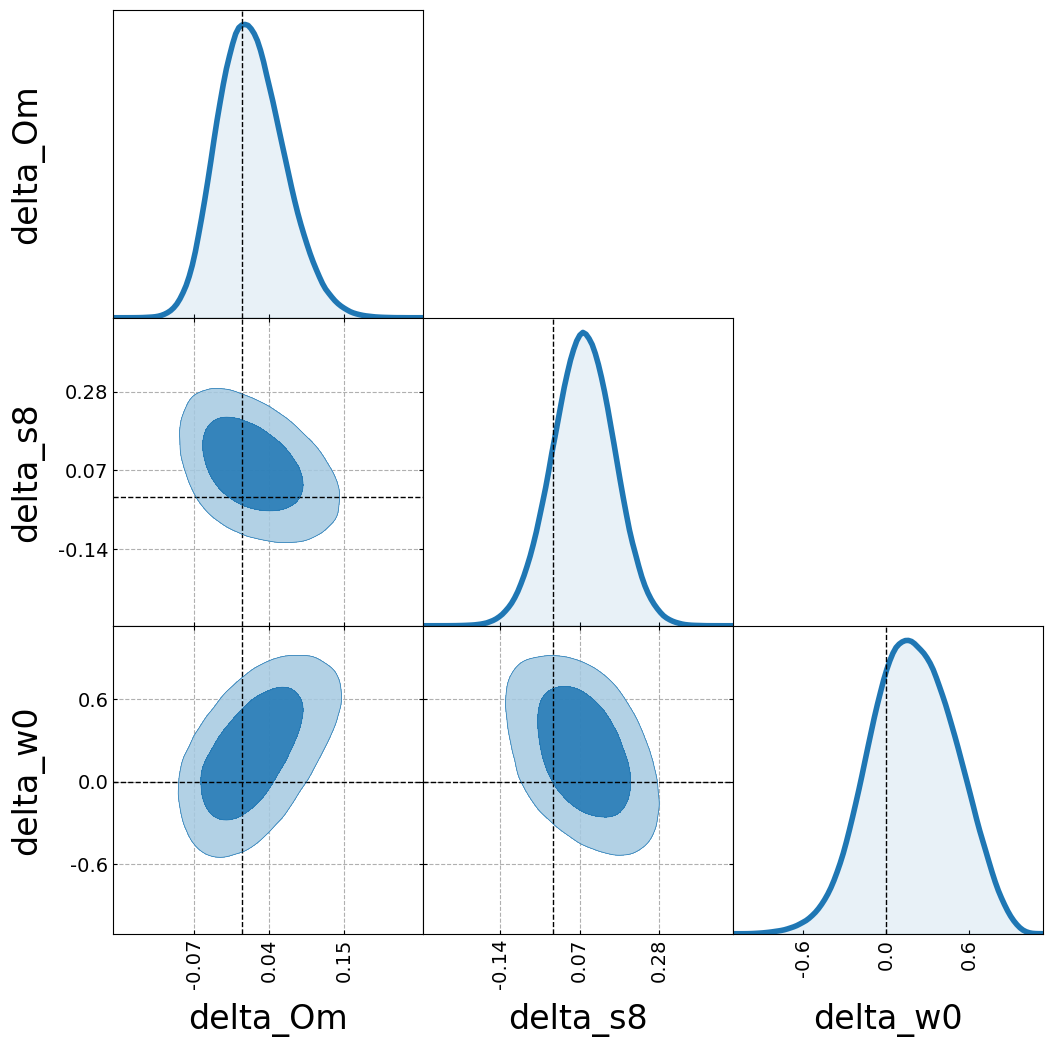

In [36]:
samples = diff_chain.samples
params = [p.name for p in diff_chain.paramNames.names]

tri = TriangleChain(
    params=params,
    fill=True,
    grid=True,
    labels=params,
    axlines_kwargs={"linestyle": "--", "lw": 1},
)

tri.contour_cl(samples, names=params);
tri.axlines(np.zeros((1,len(params))), names=params, color="k")

In [12]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=10)
# shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=10, method="brute_force")

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 3
N    samples    : 4096000
Neff samples    : 4096000.00
Smoothing scale : [0.012 0.012 0.012]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 3043 of 4096000
neighbor_elimination: chunk 2
    surviving elements 2989 of 4096000
neighbor_elimination: chunk 3
    surviving elements 2981 of 4096000
neighbor_elimination: polishing


100%|##########| 2981/2981 [10:00<00:00,  4.97it/s]


    surviving elements 2978 of 4096000
KDE method: neighbor_elimination
Time taken for KDE calculation: 673.3 (s)
Shift probability considering all parameters:
    P = 0.99927 +0.00001 -0.00001
    n_sigma = 3.379 +0.005 -0.005
